# CASE: UAV sensors — comparing calibration methods (Altum & REMX, real Plot 103 data)

**Authors:**
L. Mihai (laura.mihai@inflpr.ro)

**Extends:** [case-uav.md](https://pangeos-cost.github.io/uq-training/case-studies/case-uav/),
using real 2025 Norway field-campaign data (Plot 103) analysed under sub-optimal, variable-cloud
illumination conditions.

## What this notebook is about, in plain language

Ground spectroradiometers measure one point at a time; UAV cameras produce a full reflectance map
per flight and extract a plot value from a region of interest (ROI). This notebook uses real,
official Plot 103 results for two UAV cameras — **Altum** (5 bands) and **REMX** (10 bands) — each
processed **two different ways**: the manufacturer's grey-panel workflow, and a manual white-panel
correction. Both are real, already-computed outputs (the orthomosaic processing itself — Pix4D,
ROI extraction — is treated as a black box here, the same convention used throughout this
training module for calibration steps).

Two things are checked here, both against the official numbers directly:

1. **How much do the two calibration methods actually disagree**, band by band?
2. **Does combining the three uncertainty components (panel, plot, ROI) in simple quadrature
   reproduce the official combined uncertainty?**

**Prerequisites:** [case-uav.md](https://pangeos-cost.github.io/uq-training/case-studies/case-uav/).

# Learning objectives

**After following this notebook you will be able to ...**
- Compare two independent radiometric calibration methods (grey panel vs. manual white panel)
  applied to the *same* UAV imagery
- Reconstruct a combined uncertainty from its components and validate it against an official
  reference
- Explain why UAV uncertainty in this campaign was smaller than the ground instruments' — and why
  that is about flight timing, not inherent sensor superiority
- Recognise where a nearest-band approximation (a camera missing a wavelength an index needs)
  shows up in real data

# TOC

1. [Imports](#1)
2. [Loading real Altum and REMX results](#2)
3. [Grey panel vs. white panel: how much do they actually disagree?](#3)
4. [Reconstructing the combined uncertainty](#4)
5. [UAV vs. ground instruments: a real comparison](#5)

# 1
## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.rcParams.update({'font.size': 14})

# 2
## Loading real Altum and REMX results

[back to TOC](#TOC)

Each file has one row per band: the official reflectance and its three uncertainty components
(panel calibration, within-plot variability, and ROI-placement sensitivity), for Plot 103.

In [2]:
data_dir = Path('../data/case-uav-plot103')

altum_gp = pd.read_csv(data_dir / 'altum_greypanel.csv')
altum_wp = pd.read_csv(data_dir / 'altum_whitepanel.csv')
remx_gp  = pd.read_csv(data_dir / 'remx_greypanel.csv')
remx_wp  = pd.read_csv(data_dir / 'remx_whitepanel.csv')

print("Altum bands:", altum_gp['wvl'].tolist())
print("REMX bands:", remx_gp['wvl'].tolist())

Altum bands: [475.0, 560.0, 842.0, 668.0, 717.0]
REMX bands: [444.0, 475.0, 531.0, 560.0, 842.0, 650.0, 668.0, 705.0, 717.0, 740.0]


# 3
## Grey panel vs. white panel: how much do they actually disagree?

[back to TOC](#TOC)

Text(0.5, 0.98, 'Plot 103 — same imagery, two calibration methods')

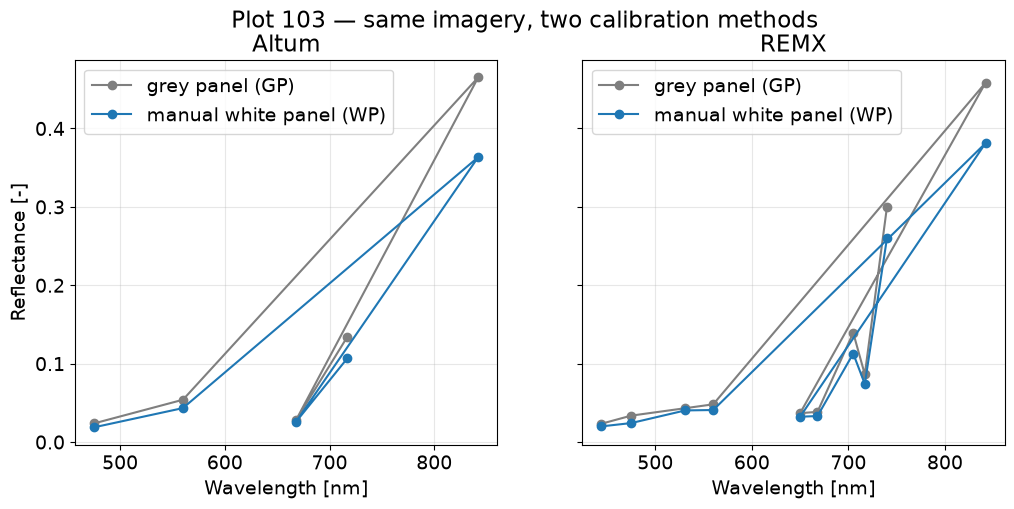

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, gp, wp, name in zip(axs, [altum_gp, remx_gp], [altum_wp, remx_wp], ['Altum', 'REMX']):
    ax.plot(gp['wvl'], gp['R'], 'o-', label='grey panel (GP)', color='tab:gray')
    ax.plot(wp['wvl'], wp['R'], 'o-', label='manual white panel (WP)', color='tab:blue')
    ax.set_xlabel('Wavelength [nm]')
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3)
axs[0].set_ylabel('Reflectance [-]')
fig.suptitle('Plot 103 — same imagery, two calibration methods')

In [4]:
for gp, wp, name in [(altum_gp, altum_wp, 'Altum'), (remx_gp, remx_wp, 'REMX')]:
    merged = gp.merge(wp, on='wvl', suffixes=('_gp', '_wp'))
    merged['rel_diff_pct'] = (merged['R_gp'] - merged['R_wp']).abs() / merged['R_gp'] * 100
    print(f"--- {name}: GP vs WP relative difference by band ---")
    print(merged[['wvl', 'R_gp', 'R_wp', 'rel_diff_pct']].round(4).to_string(index=False))
    print()

--- Altum: GP vs WP relative difference by band ---
  wvl   R_gp   R_wp  rel_diff_pct
475.0 0.0237 0.0187       20.9807
560.0 0.0539 0.0433       19.7366
842.0 0.4652 0.3635       21.8668
668.0 0.0280 0.0258        7.6450
717.0 0.1342 0.1068       20.4532

--- REMX: GP vs WP relative difference by band ---
  wvl   R_gp   R_wp  rel_diff_pct
444.0 0.0233 0.0199       14.3680
475.0 0.0337 0.0242       28.1352
531.0 0.0432 0.0403        6.5696
560.0 0.0481 0.0408       15.1117
842.0 0.4582 0.3813       16.7930
650.0 0.0368 0.0323       12.3605
668.0 0.0385 0.0332       13.8550
705.0 0.1394 0.1128       19.0434
717.0 0.0863 0.0741       14.1672
740.0 0.3004 0.2606       13.2612



<span style="color:red">
:pencil2: Your turn: is the GP/WP disagreement roughly constant across bands, or does it grow
towards the NIR band (842 nm)? If the latter — is that consistent with what
[Case: Piccolo Doppio](https://pangeos-cost.github.io/uq-training/case-studies/case-piccolo/) and
the ground spectroradiometer cases found about *where* uncertainty tends to peak?
</span>

# 4
## Reconstructing the combined uncertainty

[back to TOC](#TOC)

The official combined uncertainty for each UAV product is built from three components: panel
calibration uncertainty, within-plot variability, and sensitivity to exactly where the ROI
boundary was drawn.

$$u_c(\rho) = \sqrt{u(\text{panel})^2 + u(\text{plot})^2 + u(\text{ROI})^2}$$

In [5]:
def reconstruct_and_check(df, name):
    recomputed = np.sqrt(df['u_panel']**2 + df['u_plot']**2 + df['u_roi']**2)
    max_diff = (recomputed - df['u_total']).abs().max()
    print(f"{name}: max difference between reconstructed and official u_total = {max_diff:.2e}")
    return recomputed

for df, name in [(altum_gp, 'Altum GP'), (altum_wp, 'Altum WP'), (remx_gp, 'REMX GP'), (remx_wp, 'REMX WP')]:
    df['u_total_check'] = reconstruct_and_check(df, name)

Altum GP: max difference between reconstructed and official u_total = 3.28e-13
Altum WP: max difference between reconstructed and official u_total = 4.01e-13
REMX GP: max difference between reconstructed and official u_total = 4.53e-13
REMX WP: max difference between reconstructed and official u_total = 3.43e-13


This is an exact match (to machine precision) for all four products — unlike the ASD/SVC case
(see [`case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb`](case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb)),
where the equivalent check only approximately matched. The difference is informative: it means the
UAV pipeline combines its three components with plain quadrature, while the ground-spectrometer
pipeline combines its components through a Jacobian-weighted propagation — two genuinely different
(and each individually correct) approaches, not an inconsistency.

# 5
## UAV vs. ground instruments: a real comparison

[back to TOC](#TOC)

Which component dominates the UAV uncertainty budget, and how large is it relative to the
reflectance value itself?

In [6]:
for df, name in [(altum_wp, 'Altum (WP)'), (remx_wp, 'REMX (WP)')]:
    df['u_total_pct'] = df['u_total'] / df['R'] * 100
    dominant = df[['u_panel', 'u_plot', 'u_roi']].mean().idxmax()
    print(f"{name}: relative combined uncertainty {df['u_total_pct'].min():.2f}%-{df['u_total_pct'].max():.2f}%  "
          f"(dominant component on average: {dominant})")

Altum (WP): relative combined uncertainty 0.68%-4.36%  (dominant component on average: u_roi)
REMX (WP): relative combined uncertainty 0.55%-3.36%  (dominant component on average: u_roi)


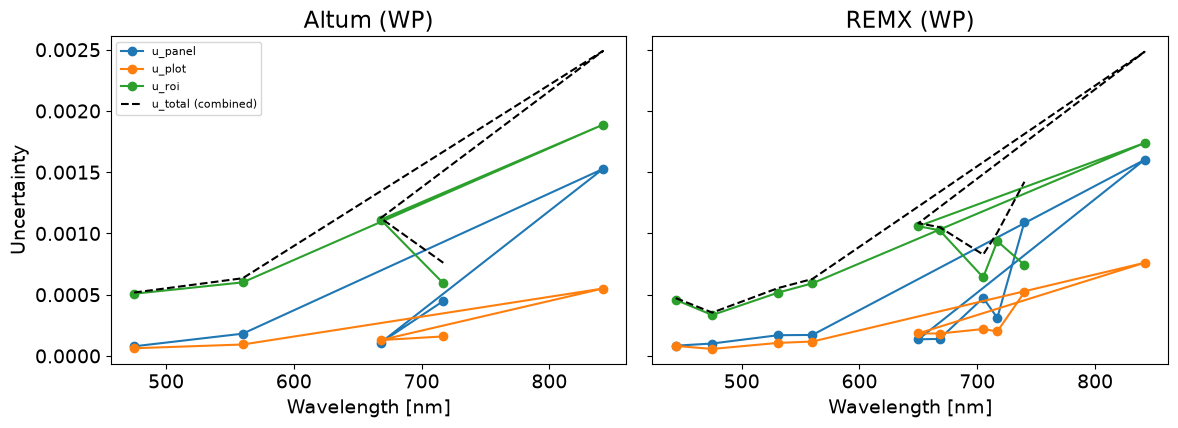

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, df, name in zip(axs, [altum_wp, remx_wp], ['Altum (WP)', 'REMX (WP)']):
    ax.plot(df['wvl'], df['u_panel'], 'o-', label='u_panel')
    ax.plot(df['wvl'], df['u_plot'], 'o-', label='u_plot')
    ax.plot(df['wvl'], df['u_roi'], 'o-', label='u_roi')
    ax.plot(df['wvl'], df['u_total'], 'k--', label='u_total (combined)')
    ax.set_title(name); ax.set_xlabel('Wavelength [nm]')
axs[0].set_ylabel('Uncertainty'); axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

<span style="color:red">
:pencil2: Your turn: compare these percentages against the ground-based cases —
[Case: Piccolo Doppio](https://pangeos-cost.github.io/uq-training/case-studies/case-piccolo/)
(peaking around 11% in the NIR) and
[`case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb`](case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb).
The UAV numbers here are far smaller — but the
[UAV case study](https://pangeos-cost.github.io/uq-training/case-studies/case-uav/) argues this is
*not* because the cameras are inherently more precise. What evidence would you need to check that
claim, beyond what is in this notebook?
</span>

## Summary and next steps

You compared two real, independent radiometric calibration methods applied to the same UAV
imagery, and reconstructed the official combined uncertainty from its three components — an exact
match, in contrast to the approximate match found for the ground spectroradiometers. That
difference is itself a real finding about how differently the two pipelines are built, not a sign
that one is more "correct" than the other.

From here:

- [Case: cross-sensor intercomparison](https://pangeos-cost.github.io/uq-training/case-studies/case-intercomparison/) —
  how a UAV result like this one gets compared against the ground instruments.
- [Case: Piccolo Doppio](https://pangeos-cost.github.io/uq-training/case-studies/case-piccolo/) —
  the reference instrument these UAV comparisons are ultimately measured against.